In [1]:
#Uploading the csv file
from google.colab import files
uploaded = files.upload()


Saving q2_customers.csv to q2_customers.csv


In [2]:
#TASK 1: Data Preparation (3 marks)
#Code Cell: Load Data + Scaling
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv('q2_customers.csv')

# Display first rows
df.head()

# Scale features
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# Convert back to DataFrame for readability
scaled_df = pd.DataFrame(scaled_data, columns=df.columns)

scaled_df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-0.725219,-0.176150,0.110166,-0.265011,-0.089951,0.550952
1,-1.488460,-1.046826,0.486157,-0.980466,-0.835176,-0.680685
2,0.176795,0.267337,-0.453822,-0.236851,-0.674046,-0.270139
3,-0.725219,-1.012309,0.298161,-0.827783,-0.996306,-1.091230
4,-1.488460,-1.034488,1.426136,-1.005986,-0.653905,-1.501776


### Why Scaling is Important for K-Means

K-Means clustering is based on distance calculations (Euclidean distance).

If features are on different scales (e.g., annual_spend vs visits_per_month), variables with larger values will dominate the clustering process.

Scaling ensures that all features contribute equally, leading to more meaningful and accurate clusters.

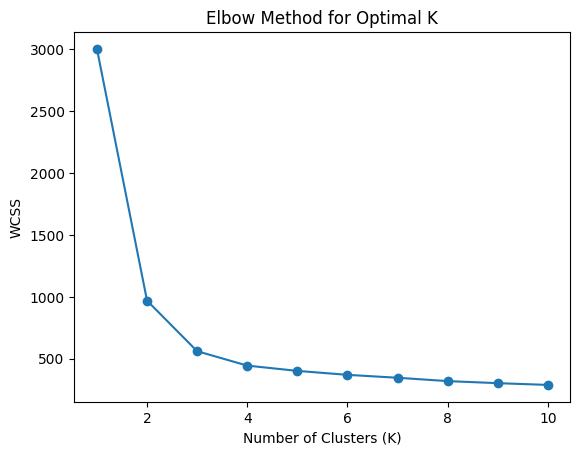

In [3]:
#TASK 2: Choosing K — Elbow Method (5 marks)
#Code Cell: Compute WCSS + Plot
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

# Compute WCSS for K = 1 to 10
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_df)
    wcss.append(kmeans.inertia_)

# Plot Elbow Graph
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()

### Choosing Optimal K using Elbow Method

The elbow method helps identify the optimal number of clusters by plotting WCSS against the number of clusters.

As K increases, WCSS decreases because clusters become smaller and tighter.

The "elbow point" is where the rate of decrease sharply slows down. This indicates that adding more clusters does not significantly improve the model.

Based on the plot, the optimal number of clusters is K = _3_ , as it represents the point where diminishing returns begin.

In [4]:
#TASK 3: K-Means Clustering (6 marks)
#Code Cell 1: Fit K-Means (K = 3)
from sklearn.cluster import KMeans

# Apply KMeans with K = 3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

clusters = kmeans.fit_predict(scaled_df)

# Add cluster labels to original dataframe
df['cluster'] = clusters

df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased,cluster
0,30,43075,9,2080,45,6,2
1,19,14496,11,454,8,3,0
2,43,57632,6,2144,16,4,2
3,30,15629,10,801,0,2,0
4,19,14901,16,396,17,1,0


In [5]:
#Code Cell 2: Cluster Centroids (Readable Format)
# Get centroids and convert to dataframe
centroids = pd.DataFrame(kmeans.cluster_centers_, columns=df.columns[:-1])

centroids

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-1.094595,-1.036122,1.114284,-0.934278,-0.813494,-1.045346
1,1.132214,1.235574,-1.106680,1.253260,1.125725,1.172991
2,-0.004449,-0.168055,-0.041370,-0.290670,-0.287579,-0.095968


### Cluster Interpretation

Cluster 0: This group may represent customers with moderate spending and average visit frequency. These customers are consistent but not highly engaged.

Cluster 1: This cluster likely includes high-value customers who spend more, visit frequently, and purchase across multiple categories. These customers are important for business revenue and should be targeted with loyalty programs.

Cluster 2: This group may consist of low-spending or inactive customers with fewer visits and lower engagement. These customers may require promotional offers to increase their activity.

These segments help the business design targeted marketing strategies for different customer groups.

In [6]:
#TASK 4: Dimensionality Reduction with PCA (5 marks)
#Code Cell 1: Apply PCA (2 Components)
from sklearn.decomposition import PCA

# Apply PCA
pca = PCA(n_components=2)

pca_components = pca.fit_transform(scaled_df)

# Convert to DataFrame
pca_df = pd.DataFrame(pca_components, columns=['PC1', 'PC2'])

pca_df.head()

,PC1,PC2
0,-0.333082,0.109379
1,-2.255362,0.048458
2,-0.092905,-0.679257
3,-2.017598,-0.308845
4,-2.917762,0.529368


In [7]:
#Code Cell 2: Explained Variance Ratio
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.83560354 0.05568764]


In [8]:
#Code Cell 3: Feature Loadings
# PCA loadings
loadings = pd.DataFrame(
    pca.components_,
    columns=scaled_df.columns,
    index=['PC1', 'PC2']
)

loadings

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.411569,0.42154,-0.410399,0.412012,0.378582,0.414017
PC2,-0.259432,-0.03327,0.208318,-0.195402,0.911194,-0.140479


### PCA Interpretation

The explained variance ratio shows how much information each principal component captures from the original data.

PC1 captures the largest variance in the dataset and is likely influenced by features such as annual_spend, basket_size, and visits_per_month, which represent overall customer activity and spending behavior.

PC2 captures the second largest variance and may represent recency-related features such as days_since_last_visit, indicating how recently a customer interacted with the business.

Thus, PC1 can be interpreted as a measure of customer value, while PC2 reflects customer engagement or recency patterns.

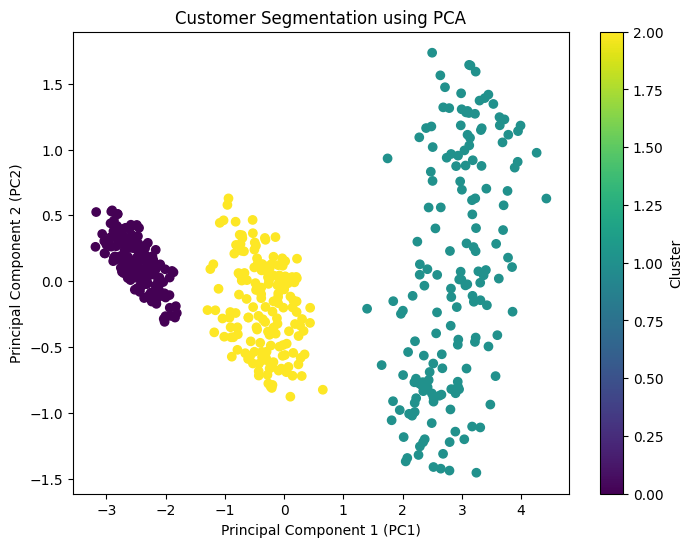

In [9]:
#TASK 5: Cluster Visualization (3 marks)
#Code Cell: Scatter Plot (PC1 vs PC2)
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    c=df['cluster'],
)

plt.title("Customer Segmentation using PCA")
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")

plt.colorbar(label='Cluster')
plt.show()

### Cluster Visualization Insight

The scatter plot shows customers projected onto two principal components (PC1 and PC2).

Each point represents a customer, and colors indicate cluster membership.

The clusters appear reasonably separated, indicating that K-Means has successfully grouped customers with similar characteristics.

This visualization helps in understanding customer segments and supports targeted marketing strategies.